Using Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


Train Samples: 48000
Validation Samples: 12000
Test Samples: 10000

Running Experiment: Activation=relu, Hidden=128, LR=0.001

Epoch [1/5] Train Loss: 0.3134 | Train Acc: 90.74% | Val Loss: 0.1679 | Val Acc: 94.92%
Epoch [2/5] Train Loss: 0.1566 | Train Acc: 95.39% | Val Loss: 0.1153 | Val Acc: 96.50%
Epoch [3/5] Train Loss: 0.1174 | Train Acc: 96.47% | Val Loss: 0.1020 | Val Acc: 96.78%
Epoch [4/5] Train Loss: 0.0993 | Train Acc: 96.91% | Val Loss: 0.0970 | Val Acc: 96.87%
Epoch [5/5] Train Loss: 0.0834 | Train Acc: 97.43% | Val Loss: 0.0848 | Val Acc: 97.24%

------------------------------
Test Results -> Accuracy: 97.63% | Loss: 0.0781
------------------------------


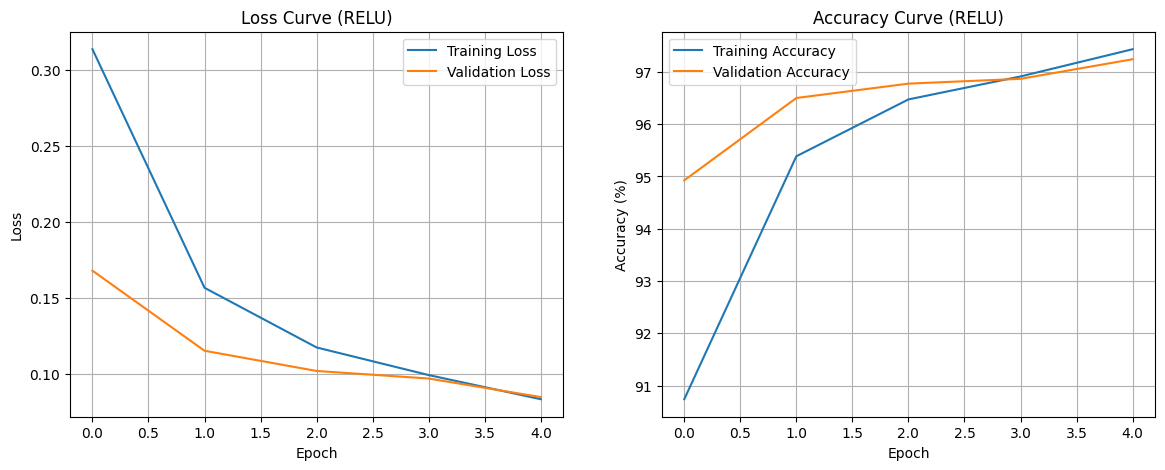


Running Experiment: Activation=tanh, Hidden=256, LR=0.001

Epoch [1/5] Train Loss: 0.2935 | Train Acc: 91.33% | Val Loss: 0.1775 | Val Acc: 94.63%
Epoch [2/5] Train Loss: 0.1456 | Train Acc: 95.73% | Val Loss: 0.1303 | Val Acc: 95.93%
Epoch [3/5] Train Loss: 0.1103 | Train Acc: 96.71% | Val Loss: 0.1126 | Val Acc: 96.47%
Epoch [4/5] Train Loss: 0.0904 | Train Acc: 97.24% | Val Loss: 0.1100 | Val Acc: 96.71%
Epoch [5/5] Train Loss: 0.0802 | Train Acc: 97.60% | Val Loss: 0.0983 | Val Acc: 96.88%

------------------------------
Test Results -> Accuracy: 97.12% | Loss: 0.0866
------------------------------


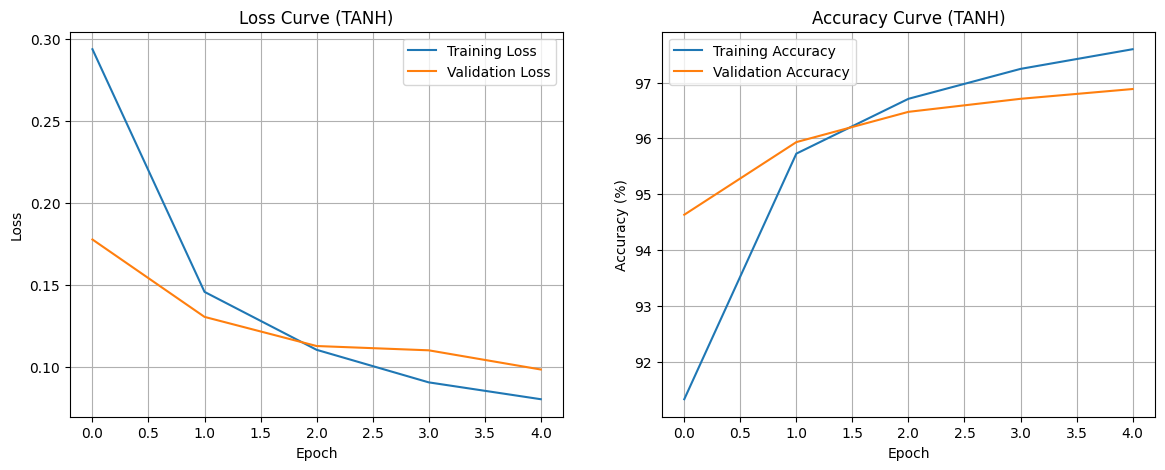


Experiments Final Comparison Table
         Experiment  Hidden Neurons Test Accuracy Test Loss
Experiment 1 (ReLU)             128        97.63%    0.0781
Experiment 2 (Tanh)             256        97.12%    0.0866

Testing Model on Real Visual Samples


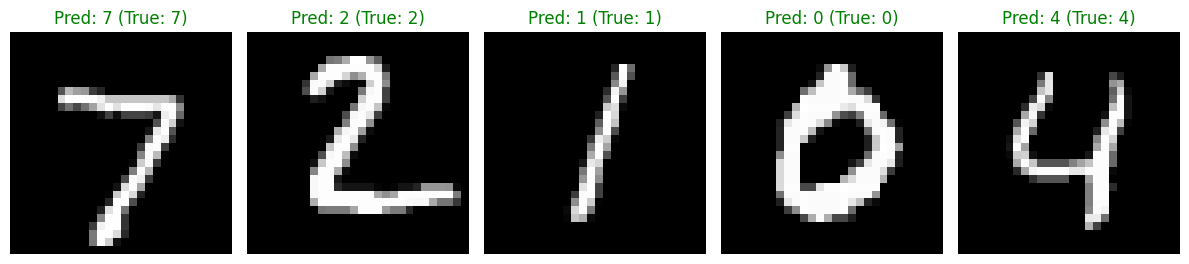


Project Finished Successfully and All Criteria Met!


In [1]:
# =========================================================
# Neural Networks Project
# Handwritten Digit Recognition (MNIST) using MLP - PyTorch
# =========================================================

# =========================
# 1. Import Libraries
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# =========================================================
# 2. Data Preprocessing
# =========================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    # تم تعديل القيم للقيم القياسية لـ MNIST لزيادة الدقة العلمية
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download dataset
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split dataset into training and validation (80% Train, 20% Val)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train Samples:", len(train_dataset))
print("Validation Samples:", len(val_dataset))
print("Test Samples:", len(test_dataset))

# =========================================================
# 3. Define MLP Model
# =========================================================
class MLP(nn.Module):
    def __init__(self, hidden_size=128, activation="relu"):
        super(MLP, self).__init__()

        if activation == "relu":
            self.activation = nn.ReLU()
        elif activation == "tanh":
            self.activation = nn.Tanh()
        elif activation == "sigmoid":
            self.activation = nn.Sigmoid()

        # Model Architecture
        self.model = nn.Sequential(
            nn.Flatten(),                      # Input Layer
            nn.Linear(28 * 28, hidden_size),   # Hidden Layer
            self.activation,
            nn.Dropout(0.2),                   # Regularization Technique
            nn.Linear(hidden_size, 10)         # Output Layer
        )

    def forward(self, x):
        return self.model(x)

# =========================================================
# 4. Training & Evaluation Function
# =========================================================
def train_model(hidden_size=128, activation="relu", learning_rate=0.001, epochs=10):
    print("\n===================================")
    print(f"Running Experiment: Activation={activation}, Hidden={hidden_size}, LR={learning_rate}")
    print("===================================\n")

    model = MLP(hidden_size=hidden_size, activation=activation).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Validation Phase
        model.eval()
        val_running_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    # Testing Phase
    test_correct, test_total, test_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    final_accuracy = 100 * test_correct / test_total
    final_loss = test_loss / len(test_loader)

    print("\n------------------------------")
    print(f"Test Results -> Accuracy: {final_accuracy:.2f}% | Loss: {final_loss:.4f}")
    print("------------------------------")

    # Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"Loss Curve ({activation.upper()})")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_accuracies, label='Training Accuracy')
    ax2.plot(val_accuracies, label='Validation Accuracy')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title(f"Accuracy Curve ({activation.upper()})")
    ax2.legend()
    ax2.grid(True)
    plt.show()

    # تعديل مهم: تم جعل الدالة تعيد الموديل المدرب لاستخدامه لاحقاً
    return model, final_accuracy, final_loss

# =========================================================
# 7. Experiment 1: ReLU + 128 Neurons
# =========================================================
model1, acc1, loss1 = train_model(hidden_size=128, activation="relu", learning_rate=0.001, epochs=5)

# =========================================================
# 8. Experiment 2: Tanh + 256 Neurons
# =========================================================
model2, acc2, loss2 = train_model(hidden_size=256, activation="tanh", learning_rate=0.001, epochs=5)

# =========================================================
# 9. Compare Results
# =========================================================
print("\n====================================")
print("Experiments Final Comparison Table")
print("====================================")
import pandas as pd
comparison_data = {
    "Experiment": ["Experiment 1 (ReLU)", "Experiment 2 (Tanh)"],
    "Hidden Neurons": [128, 256],
    "Test Accuracy": [f"{acc1:.2f}%", f"{acc2:.2f}%"],
    "Test Loss": [f"{loss1:.4f}", f"{loss2:.4f}"]
}
df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))

# =========================================================
# 10. Predict & Plot Sample Images (التعديل الاحترافي لـ التوقع الفعلي)
# =========================================================
print("\n====================================")
print("Testing Model on Real Visual Samples")
print("====================================")

# سحب عينة من الداتا لاختبارها بصرياً
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# استخدام الموديل الأول المدرب (ReLU) للتوقع
model1.eval()
with torch.no_grad():
    outputs = model1(images)
    _, preds = torch.max(outputs, 1)

# رسم أول 5 صور وعرض توقع الموديل فوقها
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img = images[i].cpu().squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {preds[i].item()} (True: {labels[i].item()})",
                      color=("green" if preds[i]==labels[i] else "red"))
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\nProject Finished Successfully and All Criteria Met!")